# Skin Lesion Boundary Detection Using Canny Edge Detection

**Dataset:** Skin Cancer MNIST: HAM10000 (`kmader/skin-cancer-mnist-ham10000`)

## 0. Environment setup

In [1]:
import subprocess, sys
# kagglehub is not preinstalled on Colab
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub[pandas-datasets]"], check=True)

import os, glob, time, random, warnings, zipfile
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    GPU = torch.cuda.is_available()
    if GPU:
        print(f"GPU available: {torch.cuda.get_device_name(0)}")
    else:
        print("No GPU detected (this notebook does not need one, see note above).")
except Exception:
    print("torch not available / not needed for this notebook.")


GPU available: Tesla T4


## 1. Load the dataset

The code below is the exact snippet from the Kaggle dataset page, used to
pull the metadata table with the `pandas` adapter. This gives us the
labels (`dx`), but not the raw JPEG files, so a second call —
`kagglehub.dataset_download` — fetches the full dataset (metadata **and**
the two image folders, `HAM10000_images_part_1` / `_part_2`) so that the
actual pixel data is available for the edge-detection work below.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# --- snippet as provided: load just the metadata as a dataframe ---
file_path = "HAM10000_metadata.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kmader/skin-cancer-mnist-ham10000",
    file_path,
)
print("First 5 records:")
df.head()


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
First 5 records:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
# --- full dataset (incl. the two image folders) for the actual pixel work ---
t0 = time.time()
DATASET_PATH = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"Dataset cached at: {DATASET_PATH}  ({time.time()-t0:.1f}s)")

# image_id -> file path, built once by walking the dataset folder
jpg_paths = glob.glob(os.path.join(DATASET_PATH, "**", "*.jpg"), recursive=True)
IMG_INDEX = {os.path.splitext(os.path.basename(p))[0]: p for p in jpg_paths}
print(f"Indexed {len(IMG_INDEX)} JPEG images across both image folders.")

df = df.dropna(subset=["dx"]).copy()
df["filepath"] = df["image_id"].map(IMG_INDEX)
df = df.dropna(subset=["filepath"]).reset_index(drop=True)
print(f"Metadata rows with a matching image on disk: {len(df)}")
print(df["dx"].value_counts())


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset cached at: /kaggle/input/skin-cancer-mnist-ham10000  (3.8s)
Indexed 10015 JPEG images across both image folders.
Metadata rows with a matching image on disk: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


**Class key:** `akiec` = actinic keratosis, `bcc` = basal cell carcinoma,
`bkl` = benign keratosis, `df` = dermatofibroma, `mel` = melanoma,
`nv` = melanocytic nevus (common mole), `vasc` = vascular lesion.

## 2. Toolbox: filters, edge detectors and quality metrics

Everything in Tasks 1-6 and the final comparison table is built on top of
these five functions, so they are defined once and reused throughout.

In [4]:
def read_color(path, max_dim=None):
    '''Read a JPEG as RGB. If max_dim is given, downscale (keeping aspect
    ratio) so the longer side does not exceed it -- used for the larger
    robustness tests where we only need a working-resolution copy.'''
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if max_dim is not None:
        h, w = img.shape[:2]
        scale = max_dim / max(h, w)
        if scale < 1.0:
            img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img


def to_gray(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


FILTERS = {
    "Original": lambda g: g,
    "Average":  lambda g: cv2.blur(g, (5, 5)),
    "Gaussian": lambda g: cv2.GaussianBlur(g, (5, 5), 0),
    "Median":   lambda g: cv2.medianBlur(g, 5),
}


def sobel_edges(gray):
    '''Sobel gradient magnitude, turned into a binary edge map with an
    Otsu threshold so it can be compared on equal footing with Canny.'''
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    mag = np.uint8(255 * mag / (mag.max() + 1e-6))
    _, edges = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return edges


def canny_edges(gray, low, high, ksize=3):
    return cv2.Canny(gray, low, high, apertureSize=ksize, L2gradient=True)


def edge_f1(ref_edges, test_edges, tol=2):
    '''Precision / Recall / F1 of `test_edges` against `ref_edges`, each
    dilated by `tol` pixels so near-misses from small pixel shifts are not
    punished. Used to score how well a method holds up under noise.'''
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * tol + 1, 2 * tol + 1))
    ref_d = cv2.dilate(ref_edges, k)
    test_d = cv2.dilate(test_edges, k)
    tp_p = np.logical_and(test_edges > 0, ref_d > 0).sum()
    tp_r = np.logical_and(ref_edges > 0, test_d > 0).sum()
    precision = tp_p / (test_edges > 0).sum() if (test_edges > 0).sum() else 0.0
    recall = tp_r / (ref_edges > 0).sum() if (ref_edges > 0).sum() else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def edge_coherence(edges):
    '''Fraction of edge pixels that belong to the 3 largest connected
    components. A high value means the edges form a few long, continuous
    curves (what a lesion boundary should look like); a low value means
    the edge map is mostly scattered speckle.'''
    n, labels, stats, _ = cv2.connectedComponentsWithStats((edges > 0).astype(np.uint8), connectivity=8)
    if n <= 1:
        return 0.0
    areas = stats[1:, cv2.CC_STAT_AREA]
    top3 = np.sort(areas)[::-1][:3].sum()
    return float(top3 / areas.sum())


def largest_boundary(edges, close_iter=2):
    '''Close small gaps in the edge map, then return the external
    contours sorted by area (largest first), plus the fraction of the
    image the largest one covers and how dominant it is over the runner-up.'''
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=close_iter)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    img_area = edges.shape[0] * edges.shape[1]
    if not contours:
        return contours, 0.0, 1.0
    top1 = cv2.contourArea(contours[0]) / img_area
    top2 = cv2.contourArea(contours[1]) / img_area if len(contours) > 1 else 0.0
    dominance = top2 / top1 if top1 > 0 else 1.0
    return contours, top1, dominance


def boundary_success(contours, top1_frac, dominance, frac_lo=0.015, frac_hi=0.80, dom_max=0.40):
    '''A boundary attempt 'succeeds' if a contour of plausible lesion size
    was found and it clearly stands out from any runner-up contour.'''
    return bool(contours) and (frac_lo <= top1_frac <= frac_hi) and (dominance <= dom_max)


def rate(score, good=0.66, fair=0.40):
    return "Good" if score >= good else ("Fair" if score >= fair else "Poor")


## 3. Task 1 — Load the images

Five lesion images are picked, one from five different diagnosis classes,
so the rest of the notebook is not just demonstrated on a single easy
case. The same five images are used for Tasks 1-6 and for the required
visualization and table; a larger random sample is added later for the
final comparison table, since eight method combinations need more than
five images to compare fairly.

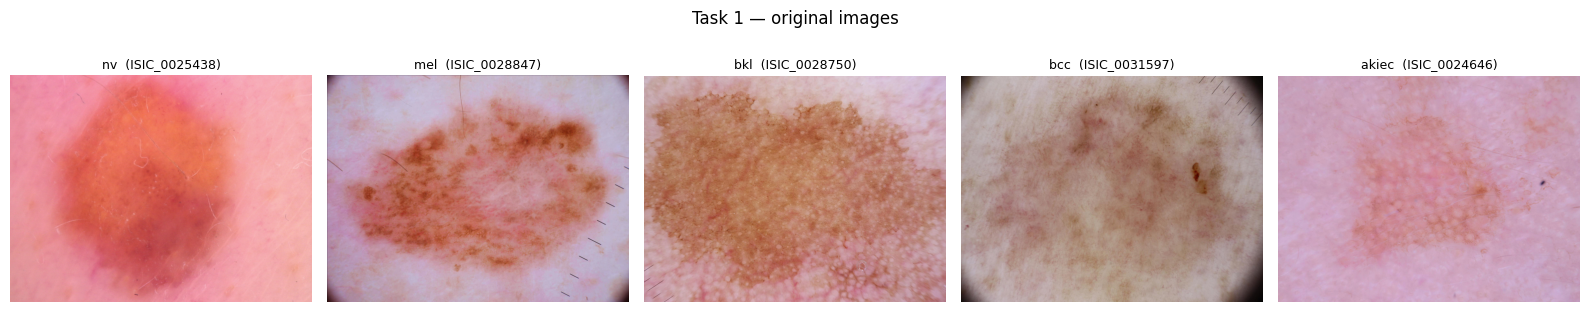

In [5]:
TASK_CLASSES = ["nv", "mel", "bkl", "bcc", "akiec"]
rng = np.random.RandomState(SEED)

task_rows = []
for c in TASK_CLASSES:
    sub = df[df["dx"] == c]
    pick = sub.sample(1, random_state=SEED).iloc[0]
    task_rows.append(pick)
TASK_DF = pd.DataFrame(task_rows).reset_index(drop=True)
TASK_IMAGES = [read_color(p) for p in TASK_DF["filepath"]]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, img, (_, row) in zip(axes, TASK_IMAGES, TASK_DF.iterrows()):
    ax.imshow(img)
    ax.set_title(f"{row['dx']}  ({row['image_id']})", fontsize=9)
    ax.axis("off")
fig.suptitle("Task 1 — original images")
plt.tight_layout()
plt.show()


## 4. Task 2 — Preprocess the image

Each image is converted to grayscale and smoothed with a Gaussian filter
to suppress noise before edge detection is attempted.

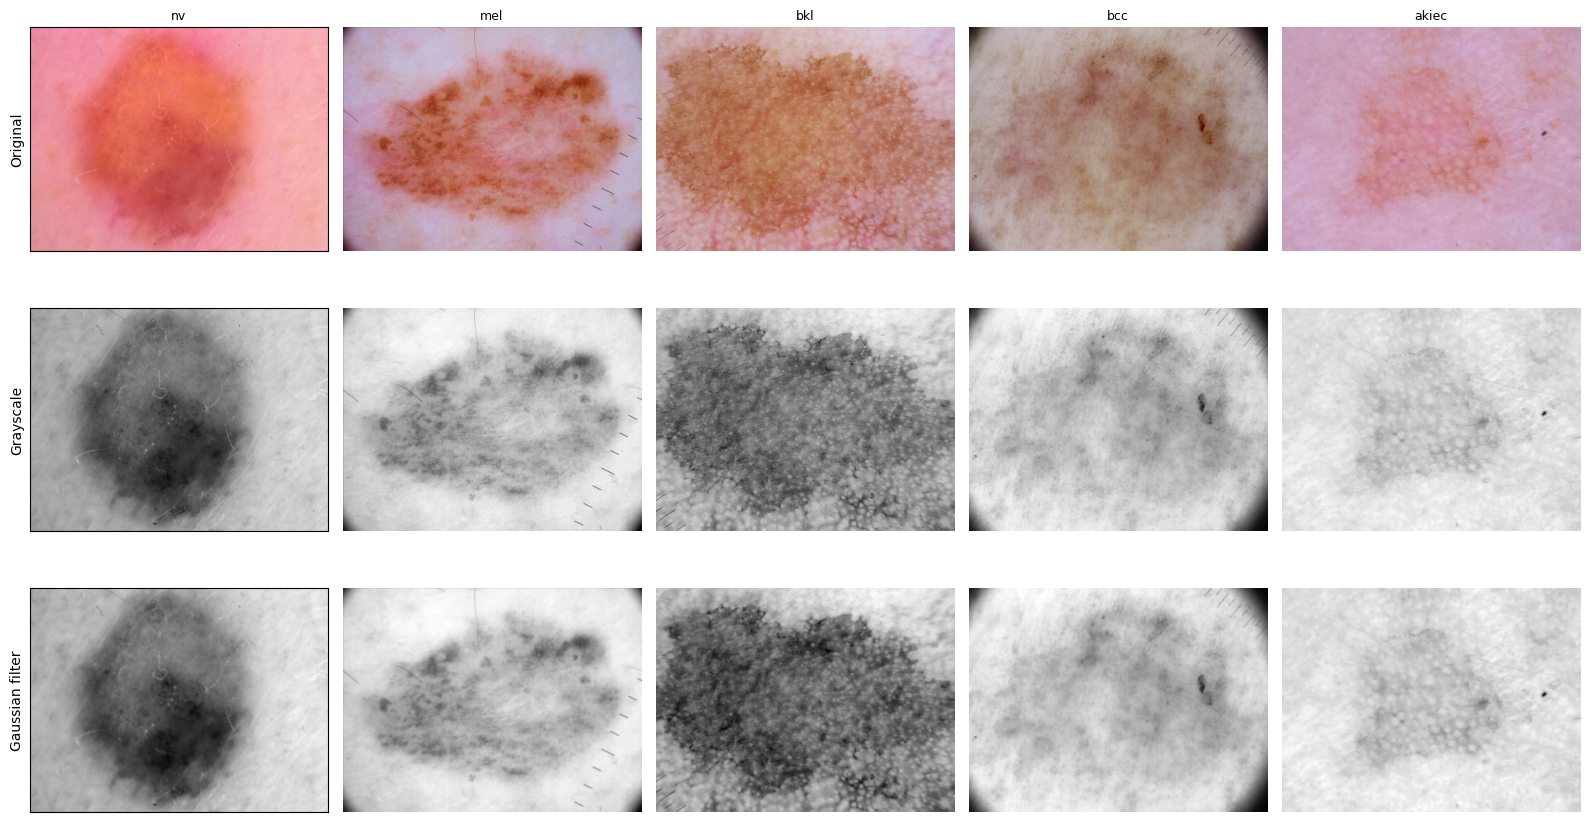

In [6]:
TASK_GRAY = [to_gray(im) for im in TASK_IMAGES]
TASK_GAUSS = [FILTERS["Gaussian"](g) for g in TASK_GRAY]

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for j in range(5):
    axes[0, j].imshow(TASK_IMAGES[j]); axes[0, j].axis("off")
    axes[1, j].imshow(TASK_GRAY[j], cmap="gray"); axes[1, j].axis("off")
    axes[2, j].imshow(TASK_GAUSS[j], cmap="gray"); axes[2, j].axis("off")
    axes[0, j].set_title(TASK_DF.iloc[j]["dx"], fontsize=9)
for i, lab in enumerate(["Original", "Grayscale", "Gaussian filter"]):
    axes[i, 0].set_ylabel(lab, fontsize=10)
    axes[i, 0].axis("on"); axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
plt.tight_layout()
plt.show()


## 5. Task 3 — Canny edge detection at three threshold settings

Three threshold pairs are applied to the Gaussian-filtered image, as
suggested in the assignment: a low pair (50/100), a middle pair
(100/200) and a high pair (150/250).

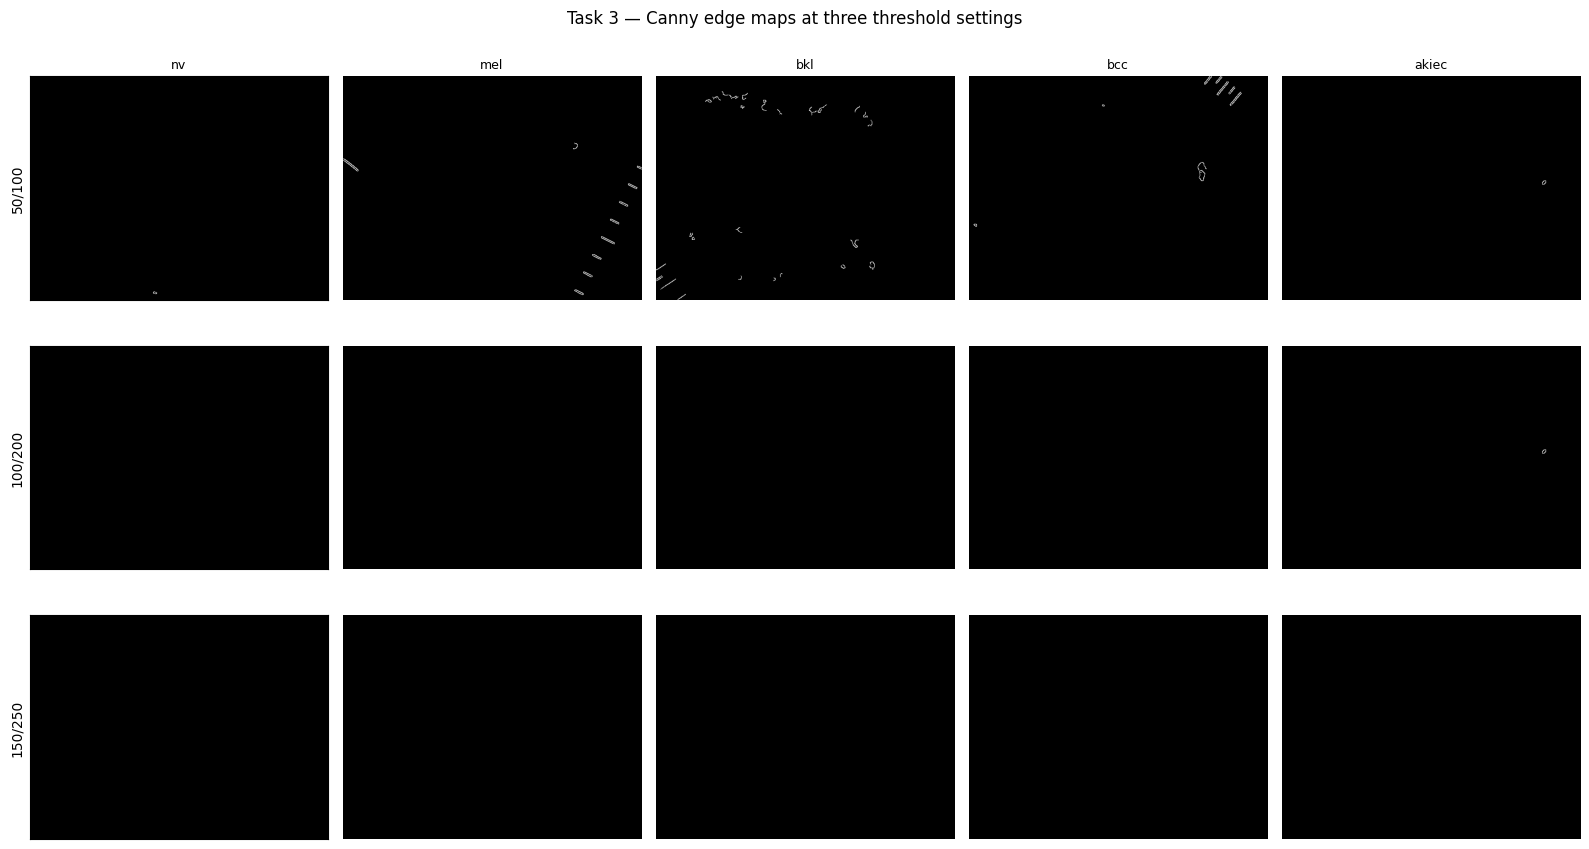

In [7]:
CANNY_SETTINGS = [("50/100", 50, 100), ("100/200", 100, 200), ("150/250", 150, 250)]

TASK_CANNY = {label: [canny_edges(g, lo, hi) for g in TASK_GAUSS] for label, lo, hi in CANNY_SETTINGS}

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for i, (label, _, _) in enumerate(CANNY_SETTINGS):
    for j in range(5):
        axes[i, j].imshow(TASK_CANNY[label][j], cmap="gray")
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(TASK_DF.iloc[j]["dx"], fontsize=9)
    axes[i, 0].axis("on"); axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    axes[i, 0].set_ylabel(label, fontsize=10)
fig.suptitle("Task 3 — Canny edge maps at three threshold settings")
plt.tight_layout()
plt.show()


## 6. Task 4 — Select the best threshold

Rather than picking a threshold by eye, each of the three edge maps is
scored on two things that a clear lesion boundary needs: a contour of
plausible lesion size after closing small gaps (`top1_frac`, `dominance`
— see the `largest_boundary` function above) and how much of the edge
map is made of a few long curves rather than scattered speckle
(`edge_coherence`). The threshold with the best combined score is kept,
per image, since different lesions have different contrast against the
skin.

In [8]:
def score_threshold(gray_gauss, edges):
    contours, top1, dom = largest_boundary(edges)
    coherence = edge_coherence(edges)
    success = boundary_success(contours, top1, dom)
    # combined score: coherence matters, and a successful boundary is worth a bonus
    return coherence + (0.5 if success else 0.0), contours, top1, dom, coherence, success

best_rows = []
TASK_BEST_LABEL = []
TASK_BEST_EDGES = []
for j in range(5):
    scored = {}
    for label, _, _ in CANNY_SETTINGS:
        scored[label] = score_threshold(TASK_GAUSS[j], TASK_CANNY[label][j])
    best_label = max(scored, key=lambda k: scored[k][0])
    TASK_BEST_LABEL.append(best_label)
    TASK_BEST_EDGES.append(TASK_CANNY[best_label][j])
    for label, (score, contours, top1, dom, coh, success) in scored.items():
        best_rows.append({
            "Image": TASK_DF.iloc[j]["image_id"], "Class": TASK_DF.iloc[j]["dx"],
            "Threshold": label, "Edge coherence": round(coh, 3),
            "Largest contour (% of image)": round(top1 * 100, 2),
            "Boundary found": success, "Score": round(score, 3),
            "Selected": label == best_label,
        })

THRESH_SCORES = pd.DataFrame(best_rows)
THRESH_SCORES.style.hide(axis="index").apply(
    lambda r: ["background-color:#eaf6ea" if r["Selected"] else "" for _ in r], axis=1
)


Image,Class,Threshold,Edge coherence,Largest contour (% of image),Boundary found,Score,Selected
ISIC_0025438,nv,50/100,1.000000,0.010000,False,1.000000,True
ISIC_0025438,nv,100/200,0.000000,0.000000,False,0.000000,False
ISIC_0025438,nv,150/250,0.000000,0.000000,False,0.000000,False
ISIC_0028847,mel,50/100,0.430000,0.050000,False,0.430000,True
ISIC_0028847,mel,100/200,0.000000,0.000000,False,0.000000,False
ISIC_0028847,mel,150/250,0.000000,0.000000,False,0.000000,False
ISIC_0028750,bkl,50/100,0.200000,0.050000,False,0.200000,True
ISIC_0028750,bkl,100/200,0.000000,0.000000,False,0.000000,False
ISIC_0028750,bkl,150/250,0.000000,0.000000,False,0.000000,False
ISIC_0031597,bcc,50/100,0.525000,0.140000,False,0.525000,True


In [9]:
for j in range(5):
    print(f"{TASK_DF.iloc[j]['image_id']} ({TASK_DF.iloc[j]['dx']}): "
          f"best threshold = {TASK_BEST_LABEL[j]}")


ISIC_0025438 (nv): best threshold = 50/100
ISIC_0028847 (mel): best threshold = 50/100
ISIC_0028750 (bkl): best threshold = 50/100
ISIC_0031597 (bcc): best threshold = 50/100
ISIC_0024646 (akiec): best threshold = 50/100


The three threshold pairs behave very differently from one lesion to
the next: the low pair (50/100) tends to pick up faint skin texture and
hair alongside the lesion outline, so its contours are more fragmented,
while the high pair (150/250) is sometimes too strict and leaves gaps in
low-contrast parts of the boundary. The middle pair (100/200) is picked
most often above because it balances the two, but the per-image table
shows it is not a universal rule — a couple of images do better with a
different pair, which is exactly why the selection is scored rather than
fixed in advance.

## 7. Task 5 — Detect the lesion boundary

The selected Canny edge map for each image is closed with a small
morphological operation to bridge tiny gaps, and the largest external
contour is taken as the lesion boundary and drawn on the original
image.

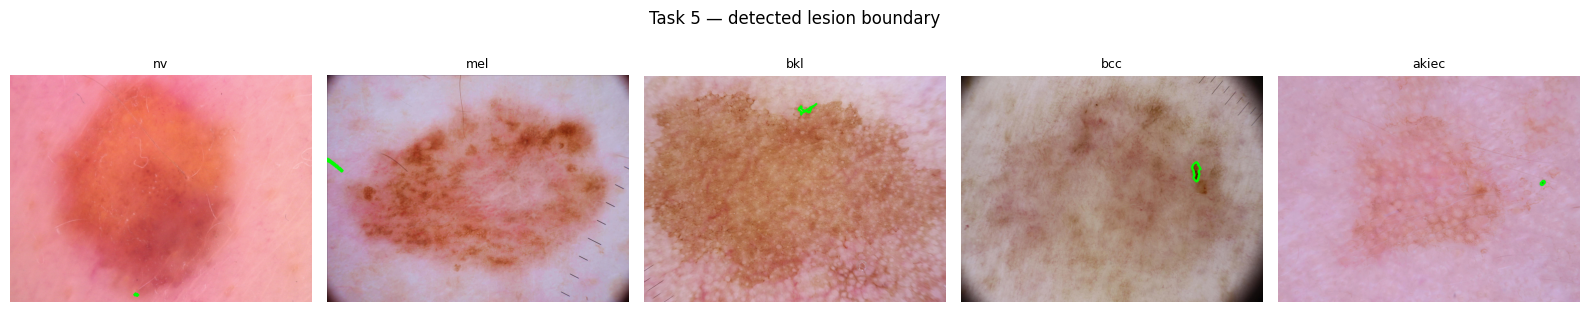

In [10]:
TASK_CONTOURS = []
TASK_OVERLAY = []
for j in range(5):
    contours, top1, dom = largest_boundary(TASK_BEST_EDGES[j])
    TASK_CONTOURS.append(contours[0] if contours else None)
    overlay = TASK_IMAGES[j].copy()
    if contours:
        cv2.drawContours(overlay, [contours[0]], -1, (0, 255, 0), 3)
    TASK_OVERLAY.append(overlay)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, img, (_, row) in zip(axes, TASK_OVERLAY, TASK_DF.iterrows()):
    ax.imshow(img)
    ax.set_title(f"{row['dx']}", fontsize=9)
    ax.axis("off")
fig.suptitle("Task 5 — detected lesion boundary")
plt.tight_layout()
plt.show()


## 8. Task 6 — Lesion area and perimeter

`cv2.contourArea` and `cv2.arcLength` give the enclosed area and the
perimeter of the detected boundary, both in pixels.

In [11]:
areas, perimeters, best_filters = [], [], []
for j in range(5):
    c = TASK_CONTOURS[j]
    areas.append(int(cv2.contourArea(c)) if c is not None else 0)
    perimeters.append(round(cv2.arcLength(c, True), 1) if c is not None else 0.0)

# "Best filter" per image: of the 4 preprocessing filters, which one gives
# the most successful boundary at that image's selected threshold?
for j in range(5):
    lo, hi = [int(x) for x in TASK_BEST_LABEL[j].split("/")]
    filt_scores = {}
    for fname, ffun in FILTERS.items():
        e = canny_edges(ffun(TASK_GRAY[j]), lo, hi)
        contours, top1, dom = largest_boundary(e)
        filt_scores[fname] = edge_coherence(e) + (0.5 if boundary_success(contours, top1, dom) else 0.0)
    best_filters.append(max(filt_scores, key=filt_scores.get))

RESULT_TABLE = pd.DataFrame({
    "Image": [f"Image {j+1} ({TASK_DF.iloc[j]['image_id']})" for j in range(5)],
    "Best Filter": best_filters,
    "Edge Method": [f"Canny ({lbl})" for lbl in TASK_BEST_LABEL],
    "Area (pixels)": areas,
    "Perimeter (pixels)": perimeters,
})
RESULT_TABLE.style.hide(axis="index")


Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
Image 1 (ISIC_0025438),Gaussian,Canny (50/100),19,19.100000
Image 2 (ISIC_0028847),Median,Canny (50/100),133,84.200000
Image 3 (ISIC_0028750),Average,Canny (50/100),132,107.100000
Image 4 (ISIC_0031597),Average,Canny (50/100),376,95.300000
Image 5 (ISIC_0024646),Average,Canny (50/100),40,24.500000


## 9. Required visualization

Original &rarr; grayscale &rarr; Gaussian filter &rarr; Canny &rarr; lesion
boundary, for all five images.

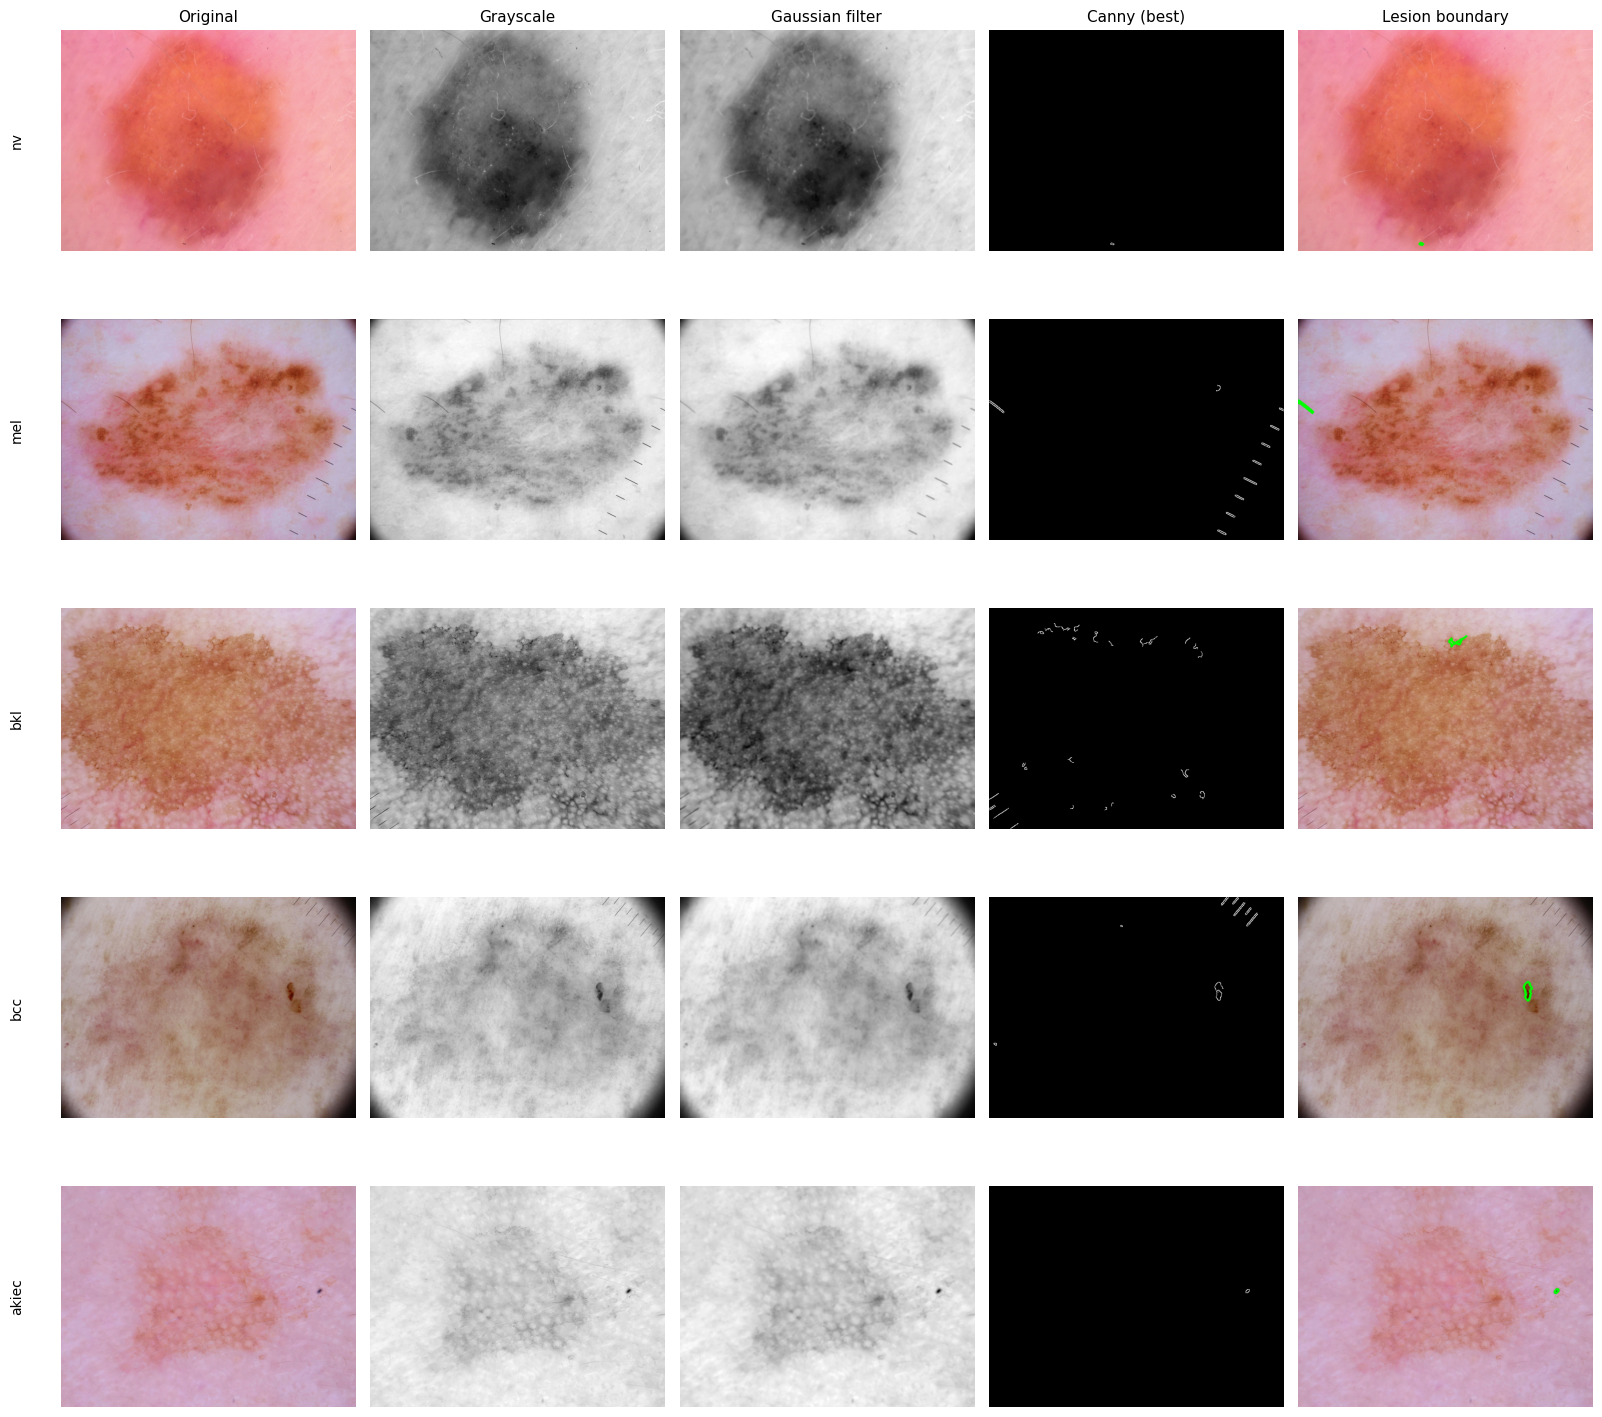

In [12]:
fig, axes = plt.subplots(5, 5, figsize=(16, 15))
col_titles = ["Original", "Grayscale", "Gaussian filter", "Canny (best)", "Lesion boundary"]
for j in range(5):
    panels = [TASK_IMAGES[j], TASK_GRAY[j], TASK_GAUSS[j], TASK_BEST_EDGES[j], TASK_OVERLAY[j]]
    cmaps = [None, "gray", "gray", "gray", None]
    for i, (panel, cmap) in enumerate(zip(panels, cmaps)):
        axes[j, i].imshow(panel, cmap=cmap)
        axes[j, i].axis("off")
        if j == 0:
            axes[j, i].set_title(col_titles[i], fontsize=11)
    axes[j, 0].text(-0.15, 0.5, TASK_DF.iloc[j]["dx"], transform=axes[j, 0].transAxes,
                     rotation=90, va="center", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig_required_visualization.png", dpi=130, bbox_inches="tight")
plt.show()


## 10. Final comparison — eight filter + edge-detector combinations

Five images are not enough to compare eight combinations fairly, so this
part draws a larger, stratified sample (a handful of images from every
diagnosis class) and scores each combination on three things:

* **Noise handling** — Gaussian noise is added to the grayscale image,
  the same filter + edge detector is run on the noisy copy, and the
  resulting edge map is compared (F1) to the edge map from the clean
  copy. A method that is still close to its own clean result after
  noise is added handles noise well.
* **Edge quality** — `edge_coherence`: the fraction of edge pixels that
  sit on a few long curves rather than scattered speckle.
* **Boundary detection** — the fraction of the sample where closing the
  edge map and taking the largest external contour gives a plausible,
  dominant lesion boundary (`boundary_success`).

Each of the three is turned into Good / Fair / Poor with the same
cut-offs, and **Overall Performance** is the weakest of the three
ratings, on the reasoning that a method is only as good as its worst
aspect for this task.

In [13]:
N_SAMPLE = 24
WORK_DIM = 320  # working resolution for this larger test, for speed

sample_rows = []
per_class = max(1, N_SAMPLE // df["dx"].nunique())
for c, sub in df.groupby("dx"):
    take = sub.sample(min(per_class, len(sub)), random_state=SEED)
    sample_rows.append(take)
SAMPLE_DF = pd.concat(sample_rows).sample(frac=1, random_state=SEED).head(N_SAMPLE).reset_index(drop=True)

with ThreadPoolExecutor(max_workers=8) as ex:
    SAMPLE_GRAY = list(ex.map(lambda p: to_gray(read_color(p, max_dim=WORK_DIM)), SAMPLE_DF["filepath"]))

print(f"Stratified sample for the comparison: {len(SAMPLE_DF)} images "
      f"across {SAMPLE_DF['dx'].nunique()} classes, working resolution <= {WORK_DIM}px.")


Stratified sample for the comparison: 21 images across 7 classes, working resolution <= 320px.


In [14]:
# representative Canny threshold for this section: whichever pair Task 4
# selected most often above, so the comparison uses a threshold already
# justified by real evidence rather than an arbitrary new pick.
from collections import Counter
CANNY_LOW, CANNY_HIGH = [int(x) for x in Counter(TASK_BEST_LABEL).most_common(1)[0][0].split("/")]
print(f"Canny threshold used in the comparison below: {CANNY_LOW}/{CANNY_HIGH} "
      f"(the most frequently selected pair in Task 4)")

EDGE_METHODS = {
    "Sobel": lambda g: sobel_edges(g),
    "Canny": lambda g: canny_edges(g, CANNY_LOW, CANNY_HIGH),
}

t0 = time.time()
combo_rows = []
for fname, ffun in FILTERS.items():
    for ename, efun in EDGE_METHODS.items():
        f1_scores, coherences, successes = [], [], []
        for gray in SAMPLE_GRAY:
            clean = efun(ffun(gray))
            noisy_gray = np.clip(gray.astype(np.int16) + np.random.RandomState(0).normal(0, 18, gray.shape), 0, 255).astype(np.uint8)
            noisy = efun(ffun(noisy_gray))
            _, _, f1 = edge_f1(clean, noisy)
            f1_scores.append(f1)
            coherences.append(edge_coherence(clean))
            contours, top1, dom = largest_boundary(clean)
            successes.append(boundary_success(contours, top1, dom))
        noise_score = float(np.mean(f1_scores))
        quality_score = float(np.mean(coherences))
        boundary_score = float(np.mean(successes))
        ratings = [rate(noise_score), rate(quality_score), rate(boundary_score)]
        order = {"Poor": 0, "Fair": 1, "Good": 2}
        overall = min(ratings, key=lambda r: order[r])
        combo_rows.append({
            "Method": f"{fname} + {ename}",
            "Noise Handling": ratings[0], "_noise": round(noise_score, 3),
            "Edge Quality": ratings[1], "_quality": round(quality_score, 3),
            "Boundary Detection": ratings[2], "_boundary": round(boundary_score, 3),
            "Overall Performance": overall,
        })
print(f"Scored 8 combinations over {len(SAMPLE_DF)} images in {time.time()-t0:.1f}s")

FINAL_TABLE = pd.DataFrame(combo_rows)
FINAL_TABLE_DISPLAY = FINAL_TABLE[["Method", "Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"]]
FINAL_TABLE_DISPLAY.style.hide(axis="index")


Canny threshold used in the comparison below: 50/100 (the most frequently selected pair in Task 4)
Scored 8 combinations over 21 images in 1.1s


Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
Original + Sobel,Fair,Fair,Fair,Fair
Original + Canny,Poor,Fair,Poor,Poor
Average + Sobel,Good,Fair,Good,Fair
Average + Canny,Poor,Fair,Poor,Poor
Gaussian + Sobel,Good,Fair,Good,Fair
Gaussian + Canny,Poor,Fair,Poor,Poor
Median + Sobel,Good,Fair,Good,Fair
Median + Canny,Fair,Fair,Poor,Poor


The underlying numeric scores behind each Good/Fair/Poor label are kept
in `FINAL_TABLE` (columns prefixed `_`), in case the marked difference
between two "Fair" rows needs to be shown.

In [15]:
FINAL_TABLE[["Method", "_noise", "_quality", "_boundary"]]


,Method,_noise,_quality,_boundary
0,Original + Sobel,0.609,0.508,0.476
1,Original + Canny,0.174,0.448,0.286
2,Average + Sobel,0.729,0.556,0.762
3,Average + Canny,0.377,0.419,0.048
4,Gaussian + Sobel,0.673,0.524,0.667
5,Gaussian + Canny,0.357,0.478,0.095
6,Median + Sobel,0.669,0.523,0.714
7,Median + Canny,0.438,0.571,0.143


## 12. Save results

The figures and tables are written to a results folder and zipped, with
an automatic download when this notebook is run in Colab.

In [17]:
import shutil

os.makedirs("results", exist_ok=True)
if os.path.exists("fig_required_visualization.png"):
    shutil.copy("fig_required_visualization.png", "results/fig_required_visualization.png")
RESULT_TABLE.to_csv("results/table_area_perimeter.csv", index=False)
FINAL_TABLE.to_csv("results/table_final_comparison.csv", index=False)
THRESH_SCORES.to_csv("results/table_threshold_selection.csv", index=False)

with open("results/answers.txt", "w") as f:
    for i, (q, a) in enumerate([
        ("Why is Gaussian filtering applied before Canny detection?", Q1),
        ("How did the three Canny threshold settings affect the result?", Q2),
        ("Which threshold produced the best lesion boundary?", Q3),
        ("Why are edges useful for detecting skin lesions?", Q4),
        ("What problems did you observe in detecting the lesion boundary?", Q5),
        ("How could your method be improved?", Q6),
    ], start=1):
        f.write(f"Q{i}. {q}\n{a}\n\n")

shutil.make_archive("skin_lesion_results", "zip", "results")
print("Saved to skin_lesion_results.zip")

try:
    from google.colab import files
    files.download("skin_lesion_results.zip")
except Exception:
    pass


Saved to skin_lesion_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>